In [1]:
import os
import math
import time
import subprocess
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from Bio import SeqIO
import torch

import matplotlib.pyplot as plt
import seaborn as sns

DATA_BASE = Path("/Users/user/data")

REF_FASTA  = DATA_BASE / "Reference/Ebola_Reference_Sequence.fasta"
DATA_FASTA = DATA_BASE / "processed/ebola_cleaned.fasta"
EMB_PT     = DATA_BASE / "embeddings/ebola_embeddings.pt"
META_CSV   = DATA_BASE / "embeddings/ebola_metadata.csv"

OUT_DIR = DATA_BASE / "results/ebola_step04A"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

COMBINED_FASTA = DATA_BASE / "interim/ebola_ref_plus_dataset.fasta"
ALN_OUT        = DATA_BASE / "interim/ebola_with_reference_aligned.fasta"
COMBINED_FASTA.parent.mkdir(parents=True, exist_ok=True)
ALN_OUT.parent.mkdir(parents=True, exist_ok=True)

print("REF exists :", REF_FASTA.exists(), REF_FASTA)
print("DATA exists:", DATA_FASTA.exists(), DATA_FASTA)
print("EMB exists :", EMB_PT.exists(), EMB_PT)
print("META exists:", META_CSV.exists(), META_CSV)
print("OUT_DIR:", OUT_DIR)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/user/miniconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/user/miniconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/user/miniconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/Users/user

REF exists : True /Users/user/data/Reference/Ebola_Reference_Sequence.fasta
DATA exists: True /Users/user/data/processed/ebola_cleaned.fasta
EMB exists : True /Users/user/data/embeddings/ebola_embeddings.pt
META exists: True /Users/user/data/embeddings/ebola_metadata.csv
OUT_DIR: /Users/user/data/results/ebola_step04A


SECTION 1 — Load and validate (FASTA + reference + metadata + embeddings)
CELL 1.1 — Load reference (1 sequence

In [3]:
def read_single_fasta(path: Path):
    recs = list(SeqIO.parse(str(path), "fasta"))
    assert len(recs) == 1, f"Expected exactly 1 sequence in {path}, found {len(recs)}"
    rec = recs[0]
    return rec.id, str(rec.seq).strip()

ref_id, ref_seq = read_single_fasta(REF_FASTA)
print("Reference ID:", ref_id)
print("Reference length:", len(ref_seq))
print("Reference preview:", ref_seq[:60], "...")

Reference ID: sp|Q05320|VGP_EBOZM
Reference length: 676
Reference preview: MGVTGILQLPRDRFKRTSFFLWVIILFQRTFSIPLGVIHNSTLQVSDVDKLVCRDKLSST ...


CELL 1.2 — Load dataset FASTA (780 sequences)

In [4]:
dataset_records = list(SeqIO.parse(str(DATA_FASTA), "fasta"))
print("Dataset sequences:", len(dataset_records))

# Convert to a DataFrame for easier joins/validation
data_rows = []
for rec in dataset_records:
    seq = str(rec.seq).strip()
    if seq:
        data_rows.append({"id": rec.id, "sequence": seq, "length": len(seq)})
dataset_df = pd.DataFrame(data_rows)
dataset_df.head(3)

Dataset sequences: 1610


,id,sequence,length
0,EBOV|20547_EMLK|KU296455|SLE|Kambia|2015-09-07,LGSFVCELGRLIIFLIEIYINLNNCYCNHTWFFRAISPRRTTVSGG...,5738
1,EBOV|PL4696|KU296513|SLE|PortLoko|2015-03-13,CELGRLIIFLIEIYINLNNCYCNHTWFFRAISPRRTTVSGGGKGIS...,5757
2,EBOV|380_EMLH|KU296377|SLE|_|2015-01-22,VCELGRLIIFLIEIYINLNNCYCNHTWFFRAISPRRTTVSGGGKGI...,5930


CELL 1.3 — Load metadata + embeddings and verify they match dataset FASTA

In [6]:
meta = pd.read_csv(META_CSV)
emb = torch.load(EMB_PT, map_location="cpu")

print("Meta:", meta.shape)
print("Emb:", type(emb), emb.shape, emb.dtype)

assert isinstance(emb, torch.Tensor) and emb.ndim == 2
assert len(meta) == emb.shape[0], "Embeddings rows must match metadata rows"
assert set(["id","sequence","embedding_idx"]).issubset(meta.columns)

# IDs must match between dataset FASTA and metadata
fasta_ids = set(dataset_df["id"])
meta_ids = set(meta["id"])
print("ID match:", fasta_ids == meta_ids, "| FASTA:", len(fasta_ids), "| META:", len(meta_ids))

if fasta_ids != meta_ids:
    print("Missing in META (sample):", list(fasta_ids - meta_ids)[:5])
    print("Missing in FASTA (sample):", list(meta_ids - fasta_ids)[:5])
    raise ValueError("FASTA and metadata IDs do not match. Stop and fix before continuing.")

# Reorder meta (and emb) to match dataset_df order by ID (important!)
meta = meta.set_index("id").loc[dataset_df["id"]].reset_index()

# Because Ebola_metadata.csv was reindexed 0..N-1 to match Ebola_embeddings.pt,
# embedding_idx should be 0..N-1 in that same order.
assert (meta["embedding_idx"].values == np.arange(len(meta))).all(), (
    "embedding_idx is not 0..N-1 after ordering by FASTA IDs. "
    "This suggests the metadata order differs from embeddings order."
)

X = emb.float()
print("✅ FASTA, metadata, embeddings are consistent. X shape:", X.shape)

Meta: (1610, 5)
Emb: <class 'torch.Tensor'> torch.Size([1610, 1280]) torch.float32
ID match: True | FASTA: 1610 | META: 1610
✅ FASTA, metadata, embeddings are consistent. X shape: torch.Size([1610, 1280])


SECTION 2 — Alignment with reference (makes position numbering real)
CELL 2.1 — Check MAFFT exists

In [7]:
def have_mafft():
    try:
        r = subprocess.run(["mafft", "--version"], capture_output=True, text=True)
        return r.returncode == 0
    except FileNotFoundError:
        return False

print("MAFFT available:", have_mafft())
if not have_mafft():
    raise RuntimeError(
        "MAFFT not installed.\n"
        "Install:\n"
        "  conda install -c bioconda mafft -y\n"
        "or macOS:\n"
        "  brew install mafft\n"
        "Then restart kernel."
    )

MAFFT available: True


CELL 2.2 — Write combined FASTA (reference first, then dataset)

In [8]:
from pathlib import Path

# Pick ONE base folder that actually contains your files
# If your files are under /Users/user/data/... use this:
DATA_BASE = Path("/Users/user/data")

REF_FASTA  = DATA_BASE / "Reference/Ebola_Reference_Sequence.fasta"
DATA_FASTA = DATA_BASE / "processed/Ebola_cleaned.fasta"

ALN_COMBINED_FASTA = DATA_BASE / "processed/ebola_ref_plus_dataset.fasta"
ALN_OUT            = DATA_BASE / "processed/ebola_with_reference_aligned.fasta"

print("REF exists:", REF_FASTA.exists(), REF_FASTA)
print("DATA exists:", DATA_FASTA.exists(), DATA_FASTA)
print("Combined FASTA will be:", ALN_COMBINED_FASTA)
print("Alignment output will be:", ALN_OUT)

REF exists: True /Users/user/data/Reference/Ebola_Reference_Sequence.fasta
DATA exists: True /Users/user/data/processed/Ebola_cleaned.fasta
Combined FASTA will be: /Users/user/data/processed/ebola_ref_plus_dataset.fasta
Alignment output will be: /Users/user/data/processed/ebola_with_reference_aligned.fasta


In [9]:
from Bio import SeqIO

# Reference
ref_recs = list(SeqIO.parse(str(REF_FASTA), "fasta"))
assert len(ref_recs) == 1, f"Expected 1 reference seq, found {len(ref_recs)}"
ref_id = ref_recs[0].id
ref_seq = str(ref_recs[0].seq).strip()

# Dataset
dataset_records = list(SeqIO.parse(str(DATA_FASTA), "fasta"))

print("Reference:", ref_id, "len:", len(ref_seq))
print("Dataset sequences:", len(dataset_records))

Reference: sp|Q05320|VGP_EBOZM len: 676
Dataset sequences: 1610


In [10]:
ALN_COMBINED_FASTA.parent.mkdir(parents=True, exist_ok=True)

with open(ALN_COMBINED_FASTA, "w") as f:
    f.write(f">{ref_id}\n{ref_seq}\n")
    for rec in dataset_records:
        seq = str(rec.seq).strip()
        if seq:
            f.write(f">{rec.id}\n{seq}\n")

print("Wrote:", ALN_COMBINED_FASTA, "bytes:", ALN_COMBINED_FASTA.stat().st_size)

Wrote: /Users/user/data/processed/ebola_ref_plus_dataset.fasta bytes: 9526247


CELL 2.3 — Run MAFFT to create MSA

In [11]:
if not ALN_OUT.exists():
    cmd = ["mafft", "--auto", str(ALN_COMBINED_FASTA)]
    print("Running:", " ".join(cmd))
    start = time.time()
    with open(ALN_OUT, "w") as f_out:
        p = subprocess.run(cmd, stdout=f_out, stderr=subprocess.PIPE, text=True)
    print("Return code:", p.returncode)
    print("MAFFT stderr tail:\n", "\n".join(p.stderr.splitlines()[-20:]))
    assert ALN_OUT.exists() and ALN_OUT.stat().st_size > 0
    print(f"✅ Alignment saved: {ALN_OUT} ({(time.time()-start)/60:.1f} min)")
else:
    print("✅ Alignment already exists:", ALN_OUT)

Running: mafft --auto /Users/user/data/processed/ebola_ref_plus_dataset.fasta
Return code: 0
MAFFT stderr tail:
 STEP  1501 / 1610 
STEP  1601 / 1610 
done.

disttbfast (aa) Version 7.526
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
0 thread(s)


Strategy:
 FFT-NS-2 (Fast but rough)
 Progressive method (guide trees were built 2 times.)

If unsure which option to use, try 'mafft --auto input > output'.
For more information, see 'mafft --help', 'mafft --man' and the mafft page.

The default gap scoring scheme has been changed in version 7.110 (2013 Oct).
It tends to insert more gaps into gap-rich regions than previous versions.
To disable this change, add the --leavegappyregion option.

✅ Alignment saved: /Users/user/data/processed/ebola_with_reference_aligned.fasta (12.6 min)


SECTION 3 — Build reference coordinate mapping (alignment pos → ref_pos)
CELL 3.1 — Load alignment and build mapping

In [12]:
GAP = "-"
AA_SET = set("ACDEFGHIKLMNPQRSTVWY")
AAS = list("ACDEFGHIKLMNPQRSTVWY")

aligned = list(SeqIO.parse(str(ALN_OUT), "fasta"))
assert aligned[0].id == ref_id, "Reference must be first record in alignment"

aln_ref_seq = str(aligned[0].seq)
aln_len = len(aln_ref_seq)
assert all(len(str(r.seq)) == aln_len for r in aligned)

dataset_aligned = [str(r.seq) for r in aligned[1:]]  # exclude reference
print("Aligned dataset sequences:", len(dataset_aligned))
print("Alignment length:", aln_len)

# mapping: alignment column -> reference position (1-based), None if ref has gap
aln_to_refpos = [None] * aln_len
ref_pos = 0
for i, ch in enumerate(aln_ref_seq):
    if ch != GAP:
        ref_pos += 1
        aln_to_refpos[i] = ref_pos

assert ref_pos == len(ref_seq)
print("✅ Built aln_to_refpos mapping. ref length:", ref_pos)

Aligned dataset sequences: 1610
Alignment length: 6074
✅ Built aln_to_refpos mapping. ref length: 676


SECTION 4 — Site-level scores: conservation, entropy, critical/hotspot (answers “where conserved/variable?”)
CELL 4.1 — Compute per-reference-position counts

In [13]:
def shannon_entropy(counts: dict):
    total = sum(counts.values())
    if total == 0:
        return 0.0
    ent = 0.0
    for c in counts.values():
        p = c / total
        ent -= p * math.log2(p)
    return ent

rows = []
N = len(dataset_aligned)

for aln_i in range(aln_len):
    refpos = aln_to_refpos[aln_i]
    if refpos is None:
        continue

    ref_aa = aln_ref_seq[aln_i]
    col = [s[aln_i] for s in dataset_aligned]
    counts_all = Counter(col)

    gap_count = counts_all.get(GAP, 0)
    aa_counts = {aa: c for aa, c in counts_all.items() if aa in AA_SET}
    total_aa = sum(aa_counts.values())

    if total_aa == 0:
        consensus = "-"
        conservation = 0.0
        entropy = 0.0
        top_aas = ""
    else:
        consensus, cons_count = max(aa_counts.items(), key=lambda x: x[1])
        conservation = cons_count / total_aa
        entropy = shannon_entropy(aa_counts)
        top = sorted(aa_counts.items(), key=lambda x: x[1], reverse=True)[:5]
        top_aas = ";".join([f"{a}:{c}" for a, c in top])

    rows.append({
        "ref_pos": int(refpos),
        "ref_aa": ref_aa,
        "consensus_aa": consensus,
        "gap_rate": gap_count / N,
        "nongap_count": int(total_aa),
        "conservation": float(conservation),  # among AAs excluding gaps
        "entropy": float(entropy),
        "top_aas": top_aas,
    })

site_df = pd.DataFrame(rows).sort_values("ref_pos").reset_index(drop=True)
print(site_df.shape)
site_df.head(5)

(676, 8)


,ref_pos,ref_aa,consensus_aa,gap_rate,nongap_count,conservation,entropy,top_aas
0,1,M,M,0.003727,1604,1.0,0.0,M:1604
1,2,G,G,0.004969,1602,1.0,0.0,G:1602
2,3,V,V,0.003727,1604,1.0,0.0,V:1604
3,4,T,T,0.003727,1604,1.0,0.0,T:1604
4,5,G,G,0.003727,1604,1.0,0.0,G:1604


CELL 4.2 — Label sites: Critical / Hotspot / etc.

In [14]:
entropy_hotspot_threshold = site_df["entropy"].quantile(0.90)

def site_category(row):
    if row["gap_rate"] > 0.5:
        return "MostlyGap"
    if row["conservation"] >= 0.95 and row["gap_rate"] <= 0.10:
        return "Critical"
    if row["conservation"] >= 0.80:
        return "Conserved"
    if row["entropy"] >= entropy_hotspot_threshold or row["conservation"] <= 0.50:
        return "Hotspot"
    return "Intermediate"

site_df["site_category"] = site_df.apply(site_category, axis=1)
site_df["site_category"].value_counts()

site_category
Critical     669
Conserved      6
MostlyGap      1
Name: count, dtype: int64

CELL 4.3 — Save site-level table

In [16]:
out_site = OUT_DIR / "Ebolaa_site_scores_reference_based.csv"
site_df.to_csv(out_site, index=False)
print("Saved:", out_site.resolve())

Saved: /Users/user/data/results/ebola_step04A/Ebolaa_site_scores_reference_based.csv


SECTION 5 — Substitution-level table: “A→V harmless vs A→D dangerous at ref_pos”
This is the direct per-position mutation scoring.

CELL 5.1 — BLOSUM62 and scoring functions

In [17]:
# BLOSUM62 table (20 AAs)
BLOSUM62 = {
"A":{"A":4,"R":-1,"N":-2,"D":-2,"C":0,"Q":-1,"E":-1,"G":0,"H":-2,"I":-1,"L":-1,"K":-1,"M":-1,"F":-2,"P":-1,"S":1,"T":0,"W":-3,"Y":-2,"V":0},
"R":{"A":-1,"R":5,"N":0,"D":-2,"C":-3,"Q":1,"E":0,"G":-2,"H":0,"I":-3,"L":-2,"K":2,"M":-1,"F":-3,"P":-2,"S":-1,"T":-1,"W":-3,"Y":-2,"V":-3},
"N":{"A":-2,"R":0,"N":6,"D":1,"C":-3,"Q":0,"E":0,"G":0,"H":1,"I":-3,"L":-3,"K":0,"M":-2,"F":-3,"P":-2,"S":1,"T":0,"W":-4,"Y":-2,"V":-3},
"D":{"A":-2,"R":-2,"N":1,"D":6,"C":-3,"Q":0,"E":2,"G":-1,"H":-1,"I":-3,"L":-4,"K":-1,"M":-3,"F":-3,"P":-1,"S":0,"T":-1,"W":-4,"Y":-3,"V":-3},
"C":{"A":0,"R":-3,"N":-3,"D":-3,"C":9,"Q":-3,"E":-4,"G":-3,"H":-3,"I":-1,"L":-1,"K":-3,"M":-1,"F":-2,"P":-3,"S":-1,"T":-1,"W":-2,"Y":-2,"V":-1},
"Q":{"A":-1,"R":1,"N":0,"D":0,"C":-3,"Q":5,"E":2,"G":-2,"H":0,"I":-3,"L":-2,"K":1,"M":0,"F":-3,"P":-1,"S":0,"T":-1,"W":-2,"Y":-1,"V":-2},
"E":{"A":-1,"R":0,"N":0,"D":2,"C":-4,"Q":2,"E":5,"G":-2,"H":0,"I":-3,"L":-3,"K":1,"M":-2,"F":-3,"P":-1,"S":0,"T":-1,"W":-3,"Y":-2,"V":-2},
"G":{"A":0,"R":-2,"N":0,"D":-1,"C":-3,"Q":-2,"E":-2,"G":6,"H":-2,"I":-4,"L":-4,"K":-2,"M":-3,"F":-3,"P":-2,"S":0,"T":-2,"W":-2,"Y":-3,"V":-3},
"H":{"A":-2,"R":0,"N":1,"D":-1,"C":-3,"Q":0,"E":0,"G":-2,"H":8,"I":-3,"L":-3,"K":-1,"M":-2,"F":-1,"P":-2,"S":-1,"T":-2,"W":-2,"Y":2,"V":-3},
"I":{"A":-1,"R":-3,"N":-3,"D":-3,"C":-1,"Q":-3,"E":-3,"G":-4,"H":-3,"I":4,"L":2,"K":-3,"M":1,"F":0,"P":-3,"S":-2,"T":-1,"W":-3,"Y":-1,"V":3},
"L":{"A":-1,"R":-2,"N":-3,"D":-4,"C":-1,"Q":-2,"E":-3,"G":-4,"H":-3,"I":2,"L":4,"K":-2,"M":2,"F":0,"P":-3,"S":-2,"T":-1,"W":-2,"Y":-1,"V":1},
"K":{"A":-1,"R":2,"N":0,"D":-1,"C":-3,"Q":1,"E":1,"G":-2,"H":-1,"I":-3,"L":-2,"K":5,"M":-1,"F":-3,"P":-1,"S":0,"T":-1,"W":-3,"Y":-2,"V":-2},
"M":{"A":-1,"R":-1,"N":-2,"D":-3,"C":-1,"Q":0,"E":-2,"G":-3,"H":-2,"I":1,"L":2,"K":-1,"M":5,"F":0,"P":-2,"S":-1,"T":-1,"W":-1,"Y":-1,"V":1},
"F":{"A":-2,"R":-3,"N":-3,"D":-3,"C":-2,"Q":-3,"E":-3,"G":-3,"H":-1,"I":0,"L":0,"K":-3,"M":0,"F":6,"P":-4,"S":-2,"T":-2,"W":1,"Y":3,"V":-1},
"P":{"A":-1,"R":-2,"N":-2,"D":-1,"C":-3,"Q":-1,"E":-1,"G":-2,"H":-2,"I":-3,"L":-3,"K":-1,"M":-2,"F":-4,"P":7,"S":-1,"T":-1,"W":-4,"Y":-3,"V":-2},
"S":{"A":1,"R":-1,"N":1,"D":0,"C":-1,"Q":0,"E":0,"G":0,"H":-1,"I":-2,"L":-2,"K":0,"M":-1,"F":-2,"P":-1,"S":4,"T":1,"W":-3,"Y":-2,"V":-2},
"T":{"A":0,"R":-1,"N":0,"D":-1,"C":-1,"Q":-1,"E":-1,"G":-2,"H":-2,"I":-1,"L":-1,"K":-1,"M":-1,"F":-2,"P":-1,"S":1,"T":5,"W":-2,"Y":-2,"V":0},
"W":{"A":-3,"R":-3,"N":-4,"D":-4,"C":-2,"Q":-2,"E":-3,"G":-2,"H":-2,"I":-3,"L":-2,"K":-3,"M":-1,"F":1,"P":-4,"S":-3,"T":-2,"W":11,"Y":2,"V":-3},
"Y":{"A":-2,"R":-2,"N":-2,"D":-3,"C":-2,"Q":-1,"E":-2,"G":-3,"H":2,"I":-1,"L":-1,"K":-2,"M":-1,"F":3,"P":-3,"S":-2,"T":-2,"W":2,"Y":7,"V":-1},
"V":{"A":0,"R":-3,"N":-3,"D":-3,"C":-1,"Q":-2,"E":-2,"G":-3,"H":-3,"I":3,"L":1,"K":-2,"M":1,"F":-1,"P":-2,"S":-2,"T":0,"W":-3,"Y":-1,"V":4},
}

def blosum_score(ref_aa, alt_aa):
    return BLOSUM62.get(ref_aa, {}).get(alt_aa, None)

def blosum_penalty(ref_aa, alt_aa):
    s = blosum_score(ref_aa, alt_aa)
    if s is None:
        return 1.0
    s = max(-4, min(4, s))
    return (4 - s) / 8.0  # 4->0, -4->1

def rarity_penalty(freq):
    # freq=0 => high penalty, freq=1 => low penalty
    return float(min(1.0, max(0.0, 1.0 - math.sqrt(freq + 1e-12))))

def impact_score(site_conservation, ref_aa, alt_aa, alt_freq,
                 w_site=0.55, w_blosum=0.30, w_rarity=0.15):
    raw = (
        w_site * float(site_conservation) +
        w_blosum * float(blosum_penalty(ref_aa, alt_aa)) +
        w_rarity * float(rarity_penalty(alt_freq))
    )
    return max(0.0, min(100.0, raw * 100.0))

def category(score):
    if score < 20: return "Harmless"
    if score < 40: return "Neutral"
    if score < 60: return "Moderate"
    if score < 80: return "Dangerous"
    return "Critical"

print("BLOSUM62 loaded. Example A->V:", blosum_score("A", "V"))
print("Example impact score:", impact_score(site_conservation=0.95, ref_aa="A", alt_aa="D", alt_freq=0.0))

BLOSUM62 loaded. Example A->V: 0
Example impact score: 89.749985


CELL 5.2 — Compute AA frequencies per ref_pos

In [18]:
# frequency per ref_pos among dataset sequences (excluding gaps)
freq_by_pos = {}

for aln_i in range(aln_len):
    refpos = aln_to_refpos[aln_i]
    if refpos is None:
        continue
    col = [s[aln_i] for s in dataset_aligned]
    aa_counts = Counter([c for c in col if c in AA_SET])
    total = sum(aa_counts.values())
    if total == 0:
        freq_by_pos[int(refpos)] = {aa: 0.0 for aa in AAS}
    else:
        freq_by_pos[int(refpos)] = {aa: aa_counts.get(aa, 0) / total for aa in AAS}

print("Example pos freq:", 1, freq_by_pos[1])

Example pos freq: 1 {'A': 0.0, 'C': 0.0, 'D': 0.0, 'E': 0.0, 'F': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'K': 0.0, 'L': 0.0, 'M': 1.0, 'N': 0.0, 'P': 0.0, 'Q': 0.0, 'R': 0.0, 'S': 0.0, 'T': 0.0, 'V': 0.0, 'W': 0.0, 'Y': 0.0}


CELL 5.3 — Generate full mutation table

In [19]:
site_metrics = site_df.set_index("ref_pos").to_dict(orient="index")

mut_rows = []
for refpos in site_df["ref_pos"].values:
    ref_aa = site_metrics[refpos]["ref_aa"]
    cons = float(site_metrics[refpos]["conservation"])

    for alt_aa in AAS:
        if alt_aa == ref_aa:
            continue

        alt_freq = float(freq_by_pos[int(refpos)].get(alt_aa, 0.0))

        s = impact_score(cons, ref_aa, alt_aa, alt_freq)  # <-- FIXED NAME

        mut_rows.append({
            "ref_pos": int(refpos),
            "ref_aa": ref_aa,
            "alt_aa": alt_aa,
            "alt_freq_in_dataset": alt_freq,
            "blosum62": blosum_score(ref_aa, alt_aa),
            "site_conservation": cons,
            "site_entropy": float(site_metrics[refpos]["entropy"]),
            "site_category": site_metrics[refpos]["site_category"],
            "impact_score": float(s),
            "impact_category": category(s),
        })

mut_df = pd.DataFrame(mut_rows)
print("Mutation table:", mut_df.shape)
mut_df.head()

Mutation table: (12844, 10)


,ref_pos,ref_aa,alt_aa,alt_freq_in_dataset,blosum62,site_conservation,site_entropy,site_category,impact_score,impact_category
0,1,M,A,0.0,-1,1.0,0.0,Critical,88.749985,Critical
1,1,M,C,0.0,-1,1.0,0.0,Critical,88.749985,Critical
2,1,M,D,0.0,-3,1.0,0.0,Critical,96.249985,Critical
3,1,M,E,0.0,-2,1.0,0.0,Critical,92.499985,Critical
4,1,M,F,0.0,0,1.0,0.0,Critical,84.999985,Critical


CELL 5.4 — Save mutation table

In [20]:
out_mut = OUT_DIR / "Ebola_mutation_scores_reference_based.csv"
mut_df.to_csv(out_mut, index=False)
print("Saved:", out_mut.resolve())

Saved: /Users/user/data/results/ebola_step04A/Ebola_mutation_scores_reference_based.csv


SECTION 6 — ESM outlier report + “hidden structure” (clusters, nearest neighbors)
What this answers
“Which sequences look most unusual?” → adaptation signals, outliers, QC anomalies
“Are there subgroups?” → hidden clusters/sublineages
“Given a new sequence embedding, what known sequences are closest?” → nearest neighbors
CELL 6.1 — Distance-to-centroid risk score (ESM)

In [21]:
def cosine_distance_to_vector(X: torch.Tensor, v: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    Xn = X / (torch.linalg.norm(X, dim=1, keepdim=True) + eps)
    vn = v / (torch.linalg.norm(v) + eps)
    sim = Xn @ vn
    return 1.0 - sim

def robust_zscore(x: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    med = x.median()
    mad = (x - med).abs().median()
    return (x - med) / (1.4826 * mad + eps)

def z_to_0_100(z: torch.Tensor, z_clip: float = 6.0) -> torch.Tensor:
    zc = torch.clamp(z, -z_clip, z_clip)
    return (zc + z_clip) * (100.0 / (2.0 * z_clip))

centroid = X.mean(dim=0)
dist_cos = cosine_distance_to_vector(X, centroid)
z = robust_zscore(dist_cos)
risk = z_to_0_100(z)

esm_report = meta.copy()
esm_report["cos_dist_to_centroid"] = dist_cos.detach().cpu().tolist()
esm_report["esm_outlier_score"] = risk.detach().cpu().tolist()
esm_report["esm_outlier_category"] = esm_report["esm_outlier_score"].map(lambda s: category(float(s)))

esm_sorted = esm_report.sort_values("esm_outlier_score", ascending=False).reset_index(drop=True)
esm_sorted[["id","length","esm_outlier_score","esm_outlier_category"]].head(15)

,id,length,esm_outlier_score,esm_outlier_category
0,EBOV|PL6070|KU296614|SLE|Kambia|2015-04-11,5769,100.0,Critical
1,EBOV|PL5428|KU296532|SLE|Kambia|2015-03-27,5832,100.0,Critical
2,EBOV|PL9199|KU296371|SLE|PortLoko|2015-07-13,5833,100.0,Critical
3,EBOV|G5364.1|KR105305|SLE|_|2014-08-28,5866,100.0,Critical
4,EBOV|G5529.1|KR105309|SLE|Kono|2014-09-05,5749,100.0,Critical
5,EBOV|MK2365|KU296363|SLE|Bombali|2015-02-25,5835,100.0,Critical
6,EBOV|G5114.1|KR105299|SLE|Pujehun|2014-08-18,5842,100.0,Critical
7,EBOV|G5304.1|KR105304|SLE|_|2014-08-28,5823,100.0,Critical
8,EBOV|REDC_GUI_2015_00483||GIN|Conakry|2015-07-12,5576,100.0,Critical
9,EBOV|EM_FORE_2015-2533||GIN|Forecariah|2015-09-26,5577,100.0,Critical


CELL 6.2 — Save ESM outlier report

In [22]:
out_esm = OUT_DIR / "Ebola_esm_outlier_report.csv"
esm_sorted.to_csv(out_esm, index=False)
print("Saved:", out_esm.resolve())

Saved: /Users/user/data/results/ebola_step04A/Ebola_esm_outlier_report.csv


CELL 6.3 — Nearest neighbors (hidden similarity)

In [23]:
# Build normalized embeddings for fast cosine similarity
Xn = X / (torch.linalg.norm(X, dim=1, keepdim=True) + 1e-12)

def top_k_neighbors(i, k=10):
    v = Xn[i]
    sims = (Xn @ v)  # cosine sim
    # exclude itself
    sims[i] = -1.0
    topv, topi = torch.topk(sims, k)
    rows = []
    for sim, j in zip(topv.tolist(), topi.tolist()):
        rows.append({"query_id": meta.loc[i, "id"], "neighbor_id": meta.loc[j, "id"], "cosine_sim": sim})
    return pd.DataFrame(rows)

# Example: neighbors of the most outlier sequence
query_idx = esm_sorted.index[0]
nn = top_k_neighbors(query_idx, k=10)
nn

,query_id,neighbor_id,cosine_sim
0,EBOV|20547_EMLK|KU296455|SLE|Kambia|2015-09-07,EBOV|19560R_EMLK|KU296580|SLE|Kambia|2015-07-07,1.000000
1,EBOV|20547_EMLK|KU296455|SLE|Kambia|2015-09-07,EBOV|020484_EMLK|KU296462|SLE|Kambia|2015-09-04,1.000000
2,EBOV|20547_EMLK|KU296455|SLE|Kambia|2015-09-07,EBOV|15338_EMLK|KU296414|SLE|Kambia|2015-06-08,1.000000
3,EBOV|20547_EMLK|KU296455|SLE|Kambia|2015-09-07,EBOV|020380_EMLK|KU296775|SLE|Kambia|2015-08-28,1.000000
4,EBOV|20547_EMLK|KU296455|SLE|Kambia|2015-09-07,EBOV|15323_EMLK|KU296668|SLE|Kambia|2015-06-07,1.000000
5,EBOV|20547_EMLK|KU296455|SLE|Kambia|2015-09-07,EBOV|19521_EMLK|KU296306|SLE|Kambia|2015-07-05,1.000000
6,EBOV|20547_EMLK|KU296455|SLE|Kambia|2015-09-07,EBOV|15438R_EMLK|KU296353|SLE|Kambia|2015-06-14,1.000000
7,EBOV|20547_EMLK|KU296455|SLE|Kambia|2015-09-07,EBOV|KT7095|KU296690|SLE|Kambia|2015-07-05,0.999998
8,EBOV|20547_EMLK|KU296455|SLE|Kambia|2015-09-07,EBOV|15543_EMLK|KU296666|SLE|Kambia|2015-06-22,0.999997
9,EBOV|20547_EMLK|KU296455|SLE|Kambia|2015-09-07,EBOV|EM_080064|KR817231|LBR|Lofa|2014-06-20,0.999989


SECTION 7 — Plots that show “what and what” clearly
CELL 7.1 — Conservation curve (critical sites & hotspots)

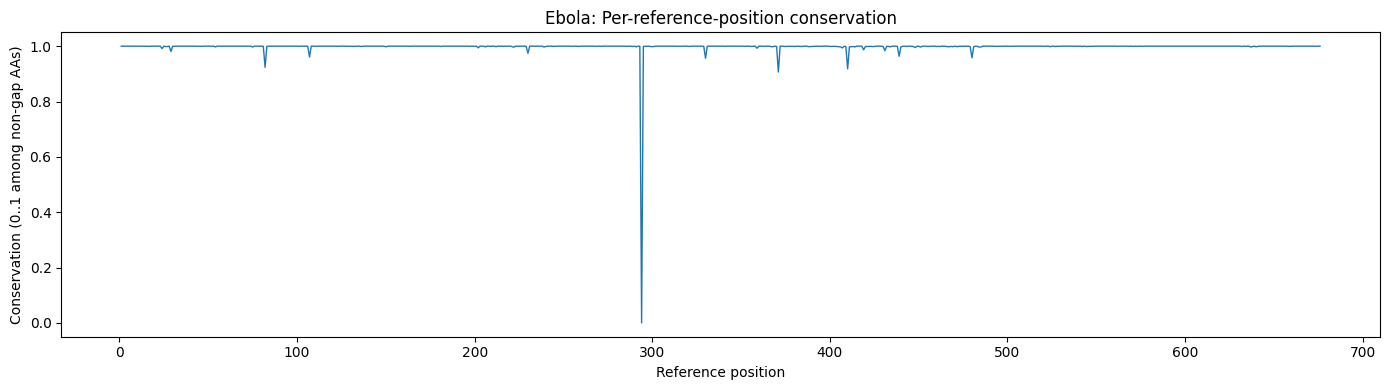

In [24]:
plt.figure(figsize=(14,4))
plt.plot(site_df["ref_pos"], site_df["conservation"], linewidth=1)
plt.title("Ebola: Per-reference-position conservation")
plt.xlabel("Reference position")
plt.ylabel("Conservation (0..1 among non-gap AAs)")
plt.tight_layout()
plt.savefig(FIG_DIR / "ebola_conservation_curve.png", dpi=200)
plt.show()

CELL 7.2 — Outlier score distribution

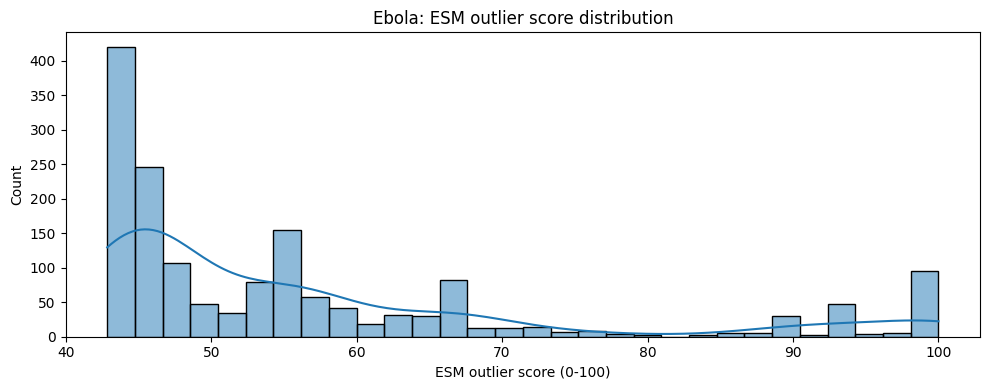

In [25]:
plt.figure(figsize=(10,4))
sns.histplot(esm_report["esm_outlier_score"], bins=30, kde=True)
plt.title("Ebola: ESM outlier score distribution")
plt.xlabel("ESM outlier score (0-100)")
plt.tight_layout()
plt.savefig(FIG_DIR / "ebola_esm_outlier_hist.png", dpi=200)
plt.show()